1. DATASET OVERVIEW
Dataset Shape: 301 rows, 9 columns

First 5 Rows:
  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  

Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year    

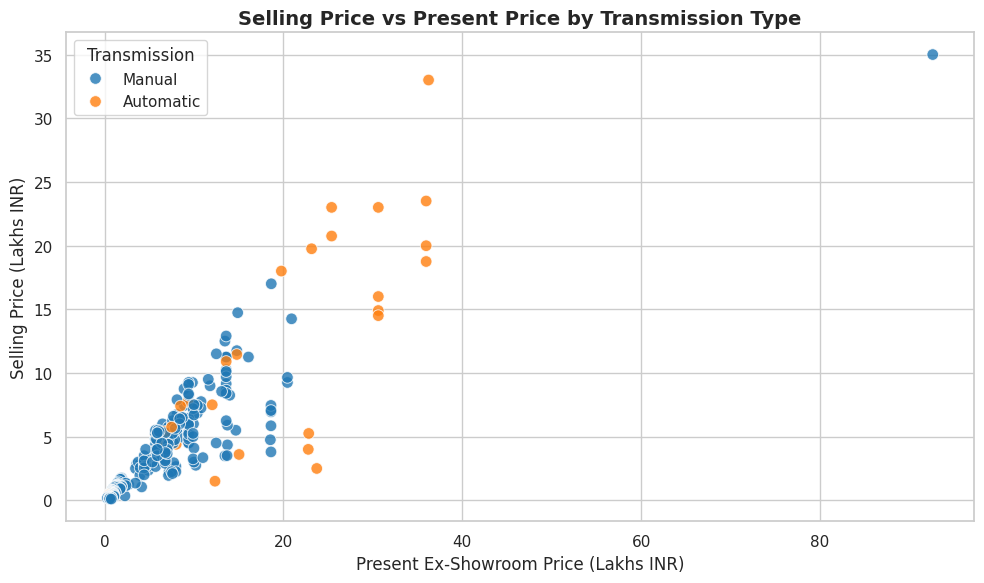

/tmp/ipykernel_1480/1639824402.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


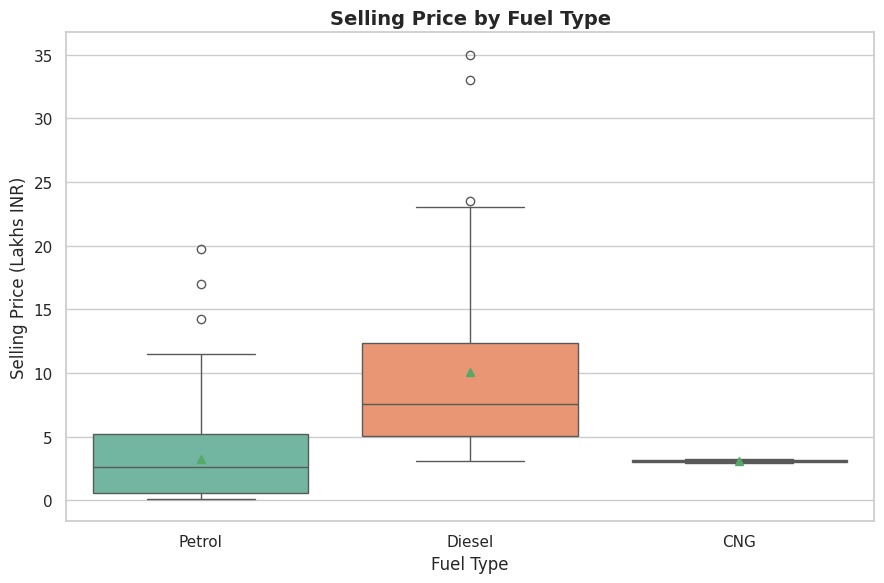

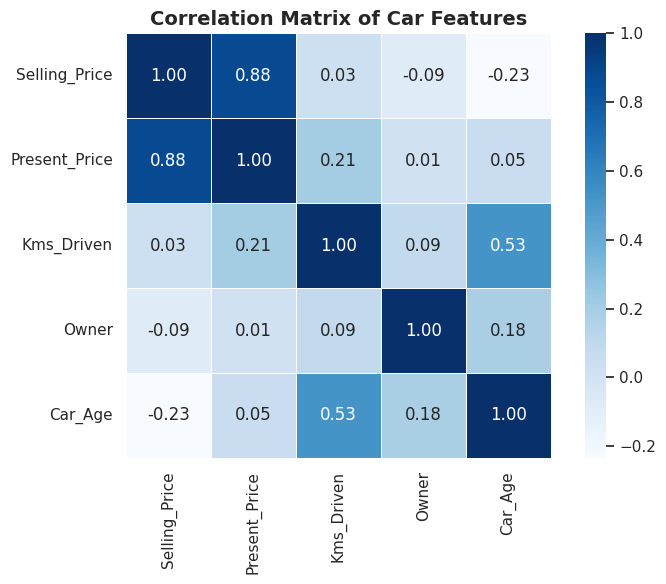

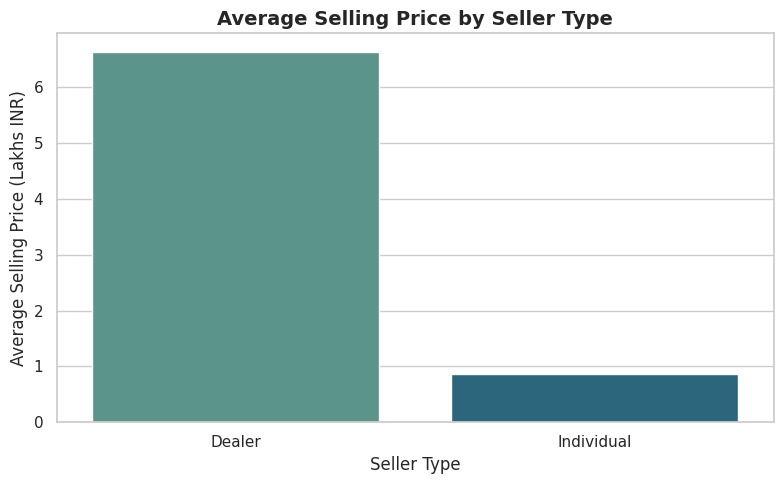


4. KEY FINDINGS & SUMMARY INSIGHTS
- Correlation between Present Price and Selling Price: 0.876
- Median Selling Price for Diesel Cars: 7.60 Lakhs
- Median Selling Price for Petrol Cars: 2.65 Lakhs
- Average Selling Price for Automatic: 9.07 Lakhs
- Average Selling Price for Manual: 3.92 Lakhs


In [1]:
"""
Car Market Trends Analysis DIY Project
Author: [Your Name]
Dataset: Car Dekho Used Car Data
Technologies: Python, Pandas, NumPy, Matplotlib, Seaborn
"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set overall visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# -------------------------------------------------------------
# 1. Load the Dataset
# -------------------------------------------------------------
DATASET_PATH = "1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv"
df = pd.read_csv(DATASET_PATH)

print("=" * 60)
print("1. DATASET OVERVIEW")
print("=" * 60)
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nFirst 5 Rows:")
print(df.head())

print("\nData Types and Missing Values:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe().T)

# -------------------------------------------------------------
# 2. Data Cleaning & Feature Engineering
# -------------------------------------------------------------
# Check for null values
null_counts = df.isnull().sum()
print("\nMissing values per column:\n", null_counts)

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows found: {duplicates}")
if duplicates > 0:
  df = df.drop_duplicates().copy()
  print(f"Shape after removing duplicates: {df.shape}")

# Calculate Car Age
CURRENT_YEAR = 2024
df["Car_Age"] = CURRENT_YEAR - df["Year"]

# -------------------------------------------------------------
# 3. Exploratory Data Analysis & Visualizations
# -------------------------------------------------------------

# Chart 1: Selling Price vs Present Price by Transmission Type
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="Present_Price",
    y="Selling_Price",
    hue="Transmission",
    palette="tab10",
    data=df,
    s=70,
    alpha=0.8,
)
plt.title(
    "Selling Price vs Present Price by Transmission Type",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Present Ex-Showroom Price (Lakhs INR)", fontsize=12)
plt.ylabel("Selling Price (Lakhs INR)", fontsize=12)
plt.tight_layout()
plt.savefig("selling_vs_present_price.png", dpi=300)
plt.show()

# Chart 2: Selling Price Distribution by Fuel Type
plt.figure(figsize=(9, 6))
sns.boxplot(
    x="Fuel_Type", y="Selling_Price", palette="Set2", data=df, showmeans=True
)
plt.title("Selling Price by Fuel Type", fontsize=14, fontweight="bold")
plt.xlabel("Fuel Type", fontsize=12)
plt.ylabel("Selling Price (Lakhs INR)", fontsize=12)
plt.tight_layout()
plt.savefig("price_by_fuel_type.png", dpi=300)
plt.show()

# Chart 3: Correlation Matrix of Numerical Variables
plt.figure(figsize=(8, 6))
numeric_cols = [
    "Selling_Price",
    "Present_Price",
    "Kms_Driven",
    "Owner",
    "Car_Age",
]
corr_matrix = df[numeric_cols].corr()
sns.heatmap(
    corr_matrix, annot=True, cmap="Blues", fmt=".2f", linewidths=0.5, square=True
)
plt.title("Correlation Matrix of Car Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300)
plt.show()

# Chart 4: Average Selling Price by Seller Type
plt.figure(figsize=(8, 5))
avg_price_seller = df.groupby("Seller_Type")["Selling_Price"].mean().reset_index()
sns.barplot(
    x="Seller_Type",
    y="Selling_Price",
    data=avg_price_seller,
    palette="crest",
    hue="Seller_Type",
    legend=False,
)
plt.title(
    "Average Selling Price by Seller Type", fontsize=14, fontweight="bold"
)
plt.xlabel("Seller Type", fontsize=12)
plt.ylabel("Average Selling Price (Lakhs INR)", fontsize=12)
plt.tight_layout()
plt.savefig("price_by_seller_type.png", dpi=300)
plt.show()

# -------------------------------------------------------------
# 4. Key Findings Output
# -------------------------------------------------------------
print("\n" + "=" * 60)
print("4. KEY FINDINGS & SUMMARY INSIGHTS")
print("=" * 60)
print(
    f"- Correlation between Present Price and Selling Price: {corr_matrix.loc['Present_Price', 'Selling_Price']:.3f}"
)
print(
    f"- Median Selling Price for Diesel Cars: {df[df['Fuel_Type'] == 'Diesel']['Selling_Price'].median():.2f} Lakhs"
)
print(
    f"- Median Selling Price for Petrol Cars: {df[df['Fuel_Type'] == 'Petrol']['Selling_Price'].median():.2f} Lakhs"
)
print(
    f"- Average Selling Price for Automatic: {df[df['Transmission'] == 'Automatic']['Selling_Price'].mean():.2f} Lakhs"
)
print(
    f"- Average Selling Price for Manual: {df[df['Transmission'] == 'Manual']['Selling_Price'].mean():.2f} Lakhs"
)